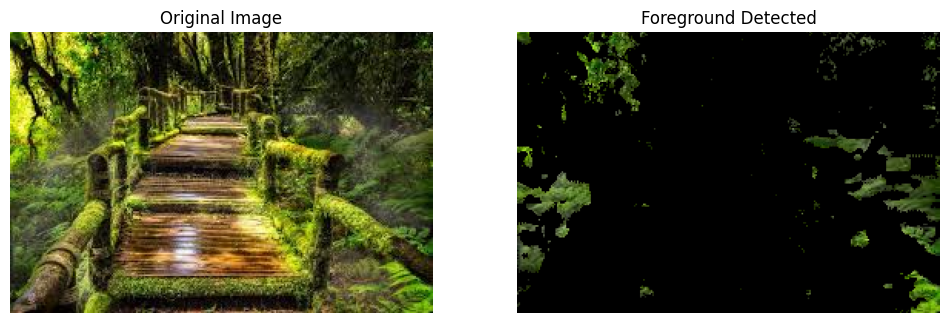

In [1]:
import cv2
import numpy as np

def subtract_foreground_by_color(image, lower_bound, upper_bound):
    """
    Subtracts the foreground of an image based on a specified color range.

    Args:
        image (numpy.ndarray): The input image in BGR format.
        lower_bound (tuple): A tuple (H, S, V) representing the lower bound of the color.
        upper_bound (tuple): A tuple (H, S, V) representing the upper bound of the color.

    Returns:
        numpy.ndarray: The foreground image (pixels within the color range).
                       Returns None if the input image is invalid.
    """
    if image is None:
        print("Error: Input image is None.")
        return None

    # Convert BGR to HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Create a mask based on the color range
    mask = cv2.inRange(hsv, lower_bound, upper_bound)

    # Invert the mask to get the background (if you want to remove the selected color)
    # Or, apply the mask to get the foreground (the selected color)
    foreground = cv2.bitwise_and(image, image, mask=mask)

    return foreground

# Example Usage:
# Load the user-provided image
image_path = '/content/images.nikki.jpg'
input_image = cv2.imread(image_path)

if input_image is None:
    print(f"Error: Could not load image from {image_path}. Please ensure the path is correct and the image exists.")
else:
    # Define a color range (e.g., for green, adjust as needed)
    # These values might need adjustment based on the specific shade of the target color in your image
    lower_color_bound = np.array([40, 40, 40]) # Example: lower bound for green in HSV
    upper_color_bound = np.array([80, 255, 255]) # Example: upper bound for green in HSV

    # Get the foreground based on the defined color range
    foreground_detected = subtract_foreground_by_color(input_image, lower_color_bound, upper_color_bound)

    # Display the original and foreground images (using matplotlib for Colab display)
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # OpenCV reads as BGR, matplotlib displays as RGB, so convert for display
    axes[0].imshow(cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    if foreground_detected is not None:
        axes[1].imshow(cv2.cvtColor(foreground_detected, cv2.COLOR_BGR2RGB))
        axes[1].set_title('Foreground Detected')
        axes[1].axis('off')

    plt.show()


### Explanation:

1.  **`subtract_foreground_by_color(image, lower_bound, upper_bound)` function**:
    *   Takes an `image` (a NumPy array in BGR format) and `lower_bound`, `upper_bound` tuples for the HSV color range.
    *   **`cv2.cvtColor(image, cv2.COLOR_BGR2HSV)`**: Converts the input BGR image to the HSV (Hue, Saturation, Value) color space. HSV is often preferred for color-based segmentation because it separates color information (Hue) from intensity (Value), making it less sensitive to lighting changes.
    *   **`cv2.inRange(hsv, lower_bound, upper_bound)`**: This is the core of color-based masking. It creates a binary mask where pixels falling within the specified `lower_bound` and `upper_bound` HSV values are set to 255 (white), and others are set to 0 (black). This mask effectively isolates the desired color.
    *   **`cv2.bitwise_and(image, image, mask=mask)`**: Applies the generated `mask` to the original image. It performs a bitwise AND operation, retaining only the pixels from the `image` where the corresponding mask pixel is white (255), thus extracting the foreground (the color within the defined range).

2.  **Example Usage**:
    *   A `dummy_image` is created with blue and green rectangles to demonstrate the functionality.
    *   `lower_green` and `upper_green` define the HSV range for green color. You'll need to adjust these values based on the specific color you want to detect in your actual images. Online HSV color pickers can be helpful for this.
    *   The `green_foreground` is extracted using the function.
    *   `matplotlib.pyplot` is used to display the original and processed images, as `cv2.imshow` does not work directly in Colab notebooks.